<a href="https://colab.research.google.com/github/anferivera/Fisica_Computacional_1/blob/main/1_PDE_theory.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PDE (Partial diferential equations)

In [1]:
import numpy as np
import matplotlib.pyplot as plta

In [14]:
#up files from Drive
from google.colab import files
from google.colab import drive
drive.mount('/content/drive')
#Read
path = 'drive/MyDrive/Colab Notebooks/Fisica_Computacional_1/figures/'
filenamePDF = 'PDF_unicity.png'
#filename1 = 'Laplace_df_1.png'
filename2 = 'Laplace_df_2.png'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Basic generalities:
See FISMAT 1 course...

The most general PDE with two independent variables (2D) is
\begin{align}
A\dfrac{\partial^2 u}{\partial x^2} + B\dfrac{\partial^2 u}{\partial x\partial y}+C\dfrac{\partial^2 u}{\partial y^2}
+D\dfrac{\partial u}{\partial x}+E\dfrac{\partial u}{\partial y} = F\,,
\end{align}
where $A,B,C,D,E,F$ are arbitrary function of the variables $x,y$.
In next, we simplified the notation, where $\dfrac{\partial u}{\partial x}=u_x$, and so on..., therefore the most general PDF can be written as:

\begin{align}
Au_{xx} + Bu_{xy}+Cu_{yy}+Du_x+Eu_y = F\,.
\end{align}

The PDE are clasified in the next form:

\begin{array}{|c|c|c|c|}
\hline
&\text{Elliptic} & \text{Parabolic} & \text{Hyperbolic} \\
\hline
&AC-B^2>0 & AC-B^2=0 & AC-B^2<0 \\
\hline
\text{Example:} & \text{Poisson}, \text{Laplace} & \text{Heat} & \text{Wave}\\
\hline
&\nabla^2u(\vec{r},t)=-4\pi\rho(\vec{r},t) & \nabla^2u(\vec{r},t)= a\dfrac{\partial}{\partial t}(\vec{r},t) & \nabla^2u(\vec{r},t)= \dfrac{1}{v^2}\dfrac{\partial^2}{\partial t^2}(\vec{r},t)\\
\hline
\end{array}


## Boundary's conditions


The unicity of the solution for each PDE is related with his boundary conditions.
* **Dirichlet boundary conditions:** The boundary condition is the value of the field on a surrounding surface.
* **Newman boundary conditions:** If the boundary condition is related to the field derivative on a surrounding surface.
* **Cauchy boundary conditions:** both Dirichlet and Newman.

In next table, we show the relation between the boundary conditions and the uniqueness for a PDE (See: A survey of Computational physics, Manuel Paez book, Métodos matematicos para físicos, G. Arfken).

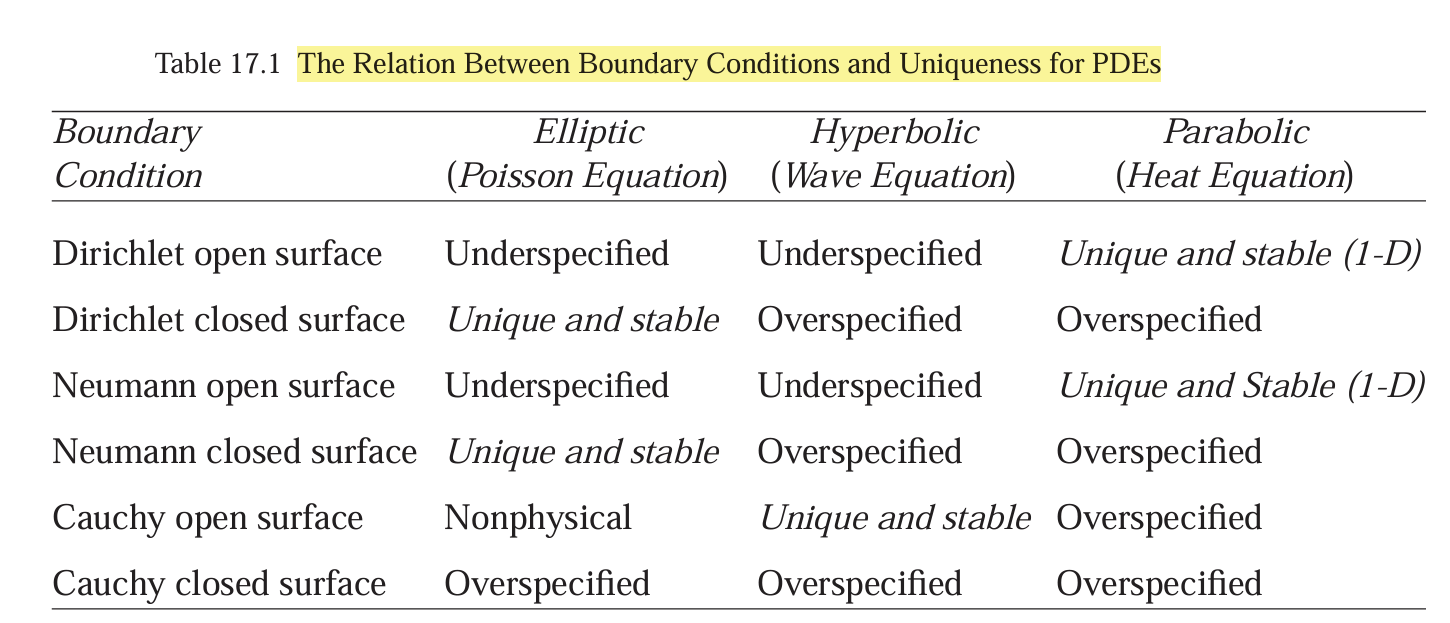

In [15]:
from IPython.display import Image
Image(filename=path+filenamePDF, width=800)

## Example 1: Laplace's equation in cartesians 2D

The Laplace equation is an **Elliptic PDE** that has an unique solution if we imposed **Dirichlet** boundary conditions.

It is known from cassical electrodynamics that the electric potential $\phi(\vec{r})=u(\vec{r})$ for satatic charges satisfied the **Poisson**'s PDF.

\begin{equation}
\nabla^2 u(\vec{r})= -4\pi \rho(\vec{r})\,
\end{equation}
where $\rho(\vec{r})$ is the charge density (Gaussian units). In charge-free regions $\rho(\vec{r})=0$ and the electric potential fulfill the **Laplace**'s equation $\nabla^{2} u(\vec{r}) =0$

For 2D Cartesian coordinates (x,y), the Laplace's equation is:
\begin{align}
\dfrac{\partial^2}{\partial x^2}u(x,y)+\dfrac{\partial^2}{\partial y^2}u(x,y)=0\,.
\end{align}
We see that the electric potential $u(x,y)$ depends simultaneously on $x$ and $y$. Notice taht in the Laplace's case, the charge, which are the souce of fields, enters indirectly in values of the electric potential in some regions of space.

In this initial notebook we will study the analiticla behaviour of the solution to the Laplace's equation for an specific case.

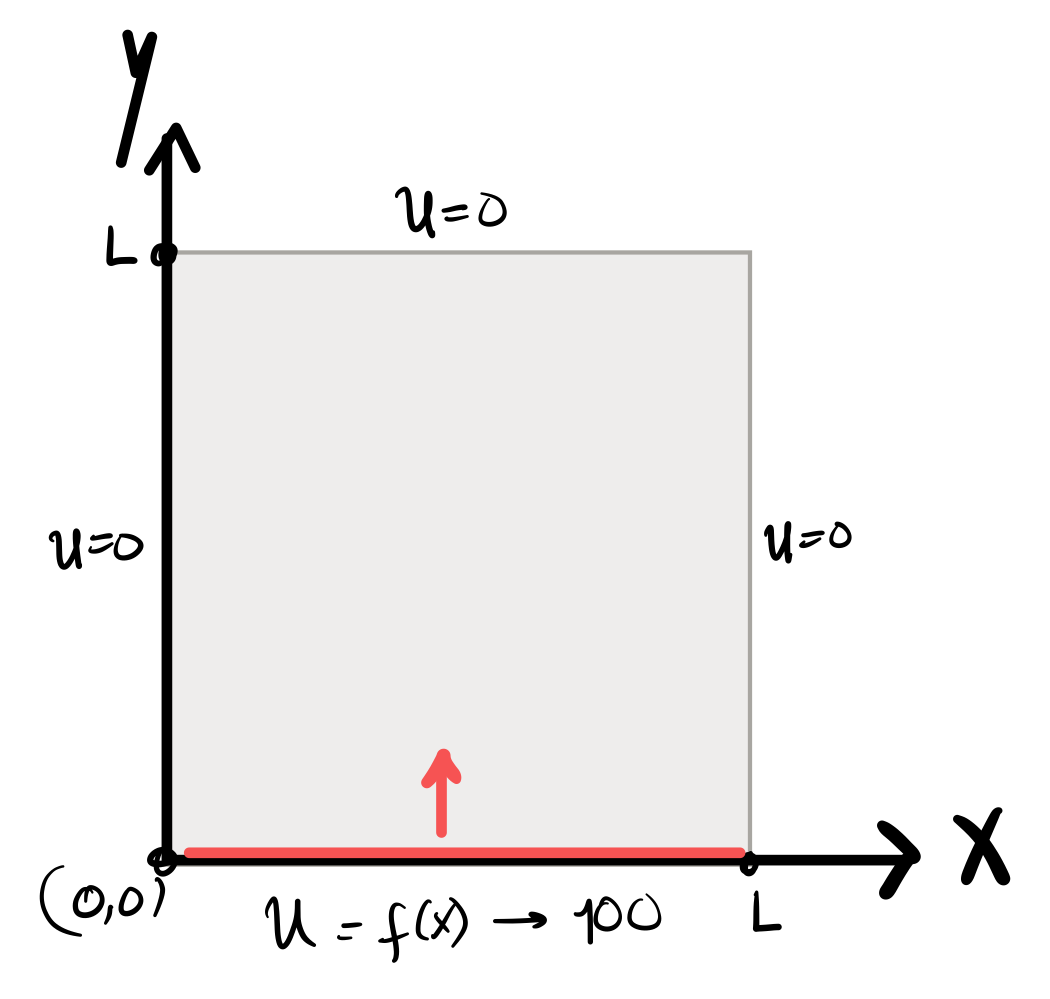

In [17]:
from IPython.display import Image
Image(filename=path+filename2, width=400)

## Example 2: Solution for the Laplace's equation
Solve the **Laplace's equation** in the dominio $0\leq x \leq L$ and $0\leq y \leq L$ with Dirichlet's boundary conditions:

* u(x,0)=V(x)=f(x)-> $V_0=$100V
* u(0,y)=0
* u(L,y)=0
* u(x,L)=0

Not continuous in the corners (y=0,L).


The solution to this PDF is obtained from the **Variable separation method**. It is given by the next Fourier's serie:

\begin{align}
u(x,y) =& \sum_{n}^{\infty}C_n\sin(\dfrac{n\pi}{L}x)\sinh(\dfrac{n\pi}{L}(L-y))\\
=& \sum_{n=1,3,5,7}^{\infty}\dfrac{4\,V_0}{n\pi}\sin(\dfrac{n\pi}{L}x)\sinh(\dfrac{n\pi}{L}(L-y))/\sinh(n\pi)
\end{align}

Homework: Show the last relation.



## Programing the solution

For this example we will consider $V_0=100$ V and $L=1$ m.

In [18]:
#Define the n-esimo modo
def un(x,y,n=1,L=1):
  'function to compute the n-esimo term of the Fouriers serie'
  v0 = 100 #Voltage
  return (4*v0/(n*np.pi))*np.sin(n*np.pi*x/L)*np.sinh(n*np.pi*(L-y)/L)/np.sinh(n*np.pi)

In [21]:
#Making the grid to do the plot
L = 1 #longitude
coordx = np.linspace(0,L,100) # 100 puntos
coordy = coordx
x , y = np.meshgrid(coordx, coordy, indexing= 'ij')

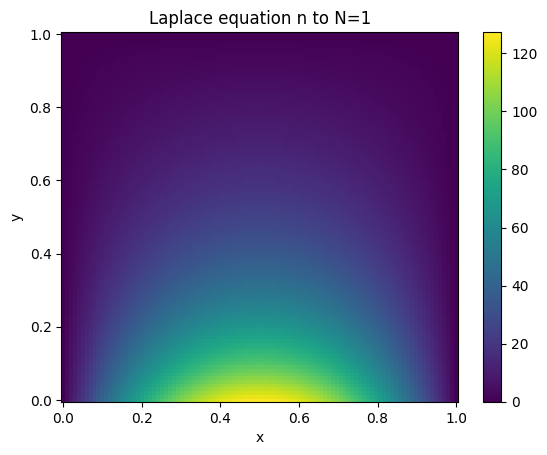

In [22]:
#Plot to N-1 frecuencies
N = 2
z = 0
for n in range(1,N,2): #Only odd n values
  z += un(x,y,n,L)

plt.pcolor(x, y, z)
plt.colorbar()
plt.xlabel('x')
plt.ylabel('y')
plt.title(f'Laplace equation n to N=%.f'%(N-1))
plt.show()

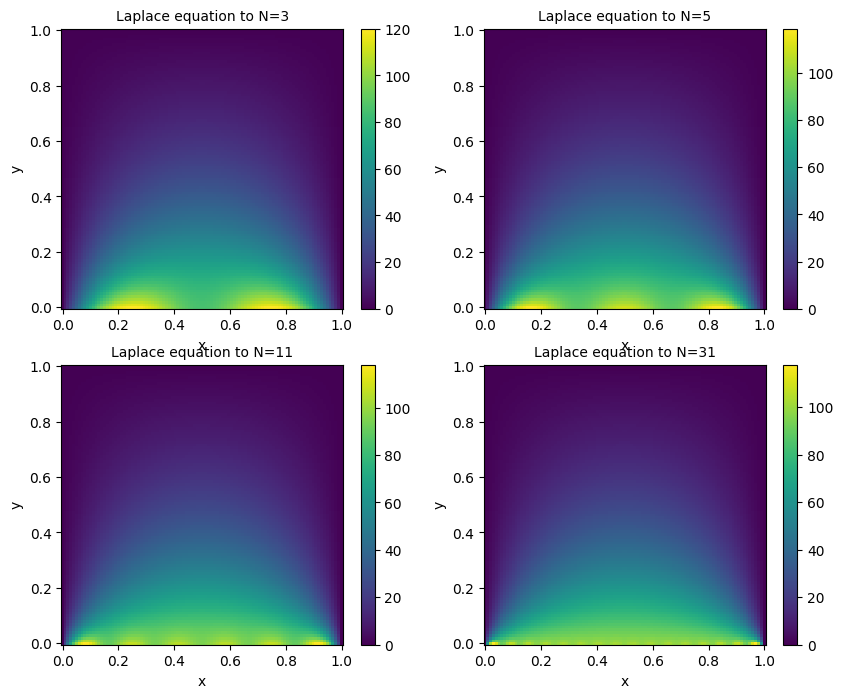

In [23]:
fig, ax= plt.subplots(2,2,figsize=(10,8))
#************************************
N = 4 #Plot for N frecuencies
z = 0
for n in range(1,N,2): #Only odd n values
  z += un(x,y,n,L)
im = ax[0,0].pcolor(x, y, z)
fig.colorbar(im, ax=ax[0,0])
ax[0,0].set_xlabel('x')
ax[0,0].set_ylabel('y')
ax[0,0].set_title(f'Laplace equation to N=%.f'%(N-1), size=10)
#************************************
N = 6 #Plot for N frecuencies
z = 0
for n in range(1,N,2): #Only odd n values
  z += un(x,y,n,L)
im = ax[0,1].pcolor(x, y, z)
fig.colorbar(im, ax=ax[0,1])
ax[0,1].set_xlabel('x')
ax[0,1].set_ylabel('y')
ax[0,1].set_title(f'Laplace equation to N=%.f'%(N-1), size=10)
#************************************
N = 12 #Plot for N frecuencies
z = 0
for n in range(1,N,2): #Only odd n values
  z += un(x,y,n,L)
im = ax[1,0].pcolor(x, y, z)
fig.colorbar(im, ax=ax[1,0])
ax[1,0].set_xlabel('x')
ax[1,0].set_ylabel('y')
ax[1,0].set_title(f'Laplace equation to N=%.f'%(N-1), size=10)
#************************************
N = 32 #Plot for N frecuencies
z = 0
for n in range(1,N,2): #Only odd n values
  z += un(x,y,n,L)
im = ax[1,1].pcolor(x, y, z)
fig.colorbar(im, ax=ax[1,1])
ax[1,1].set_xlabel('x')
ax[1,1].set_ylabel('y')
ax[1,1].set_title(f'Laplace equation to N=%.f'%(N-1), size=10)

plt.show()

Notice the oscillations in x. As an algorithm we have to stop at some point. However, the serie converges so slowly (problem). Also, notice that $\sinh(n\pi y)$ function overflow for large $n$. vlaues.

Plot 3D: let's do a 3D plot

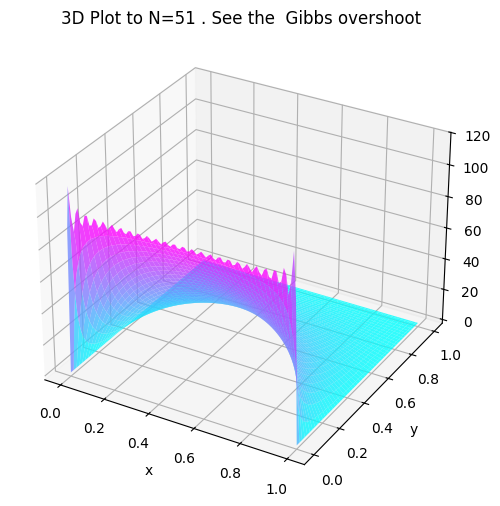

In [24]:
#Plot to N-1 frecuencies
N = 52
z = 0
for n in range(1,N,2): #Only odd n values
  z += un(x,y,n,L)

fig = plt.figure(figsize=(8, 6))
ax = plt.axes(projection='3d')
ax.plot_surface(x, y, z, cmap='cool', alpha=0.8)
ax.set_title('3D Plot to N=%.1d . See the  Gibbs overshoot'%(N-1))
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
plt.show()

### Gibbs overshoot

Notice that the serie develops large oscillations that tends to overshoot the corners **Gibbs overshoot**. It occurs when a finite terms is used to represent the solution. In next 3D plot it is shown for a large $n$ value (the smooth solution is obtained with $n=40000$... literature).